In [1]:
import xarray as xr
import numpy as np
from os import path
from snow_analysis import compute_grid_cell_area

In [73]:
cell_area = compute_grid_cell_area(ds_47.snow_storage)

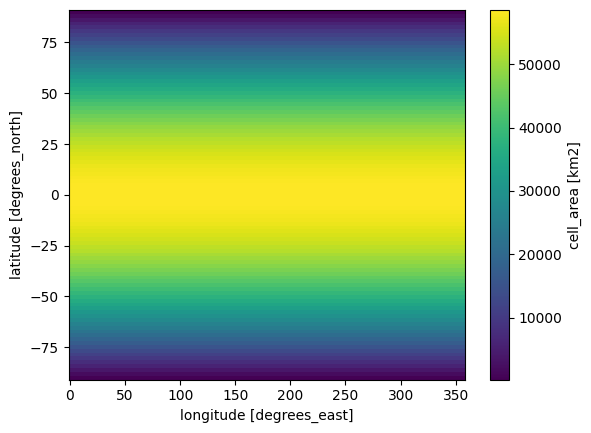

In [74]:
cell_area.plot()

In [2]:
def extract_cell_areas(da: xr.DataArray, cell_areas: xr.DataArray) -> np.ndarray:
    """
    Extracts cell areas for land cells using the same mask as prepare_time_series.
    Arguments:
        da: xr.DataArray, shape (time, lat, lon) - original data (used for land mask)
        cell_areas: xr.DataArray, shape (lat, lon) - cell areas
    Returns:
        areas_1d: np.ndarray, shape (n_land_cells,)
    """
    land_mask = ~np.isnan(da.isel(time=0))
    areas_1d = cell_areas.values[land_mask.values]  # shape: (n_land_cells,)
    return areas_1d

In [72]:
ds_47.snow_storage.isel(time=0).values[75:100]

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0., nan,  0., ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [7]:
days_in_month = ds_47.snow_storage.time.dt.days_in_month  # shape: (time,)
days_in_month

<xarray.DataArray 'days_in_month' (time: 180)>
array([28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31,
       31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31,
       28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31,
       31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31,
       28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31,
       31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31,
       28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31,
       31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31,
       28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31,
       31, 30, 31, 30, 31, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31])
Coordinates:
  * time     (time) object 0005-02-01 00:00:00 ... 0020-01-01 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bnds

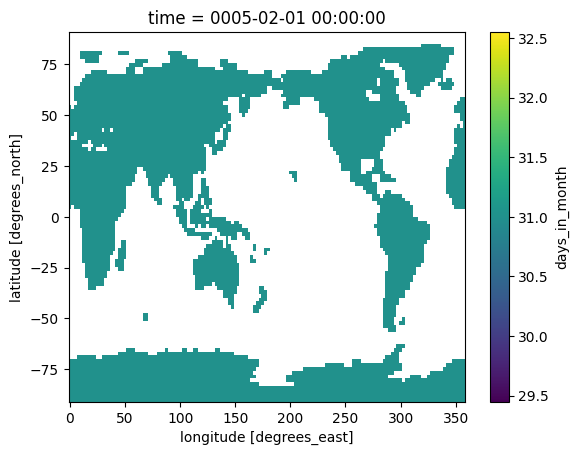

In [5]:
ds_47.days_in_month.isel(time=0).plot()

In [2]:
ds_47 = xr.open_dataset("./results/47/snow_47.nc")
labels = np.load("./results/47/47_Tg/5_cluster_labels.npy")
mask_alt = xr.open_dataarray("./data/interim/alte Masken/land_mask_alt.nc")

In [38]:
mask_neu = xr.open_dataarray("./data/interim/land_mask_neu.nc")

In [49]:
mask_neu

<xarray.DataArray (lat: 96, lon: 144)>
[13824 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:  Land fraction
    units:      1

In [ ]:
# Alle Werte in neuer_maske auf 0 setzen, wo alte_maske 0 ist
mask_neu.values[mask_alt.values == 0] = 0

mask_neu.to_netcdf("./data/interim/land_mask_neu.nc")

In [19]:
from src.processing.clustering import prepare_time_series
timeseries = prepare_time_series(ds_47.snow_storage)

In [67]:
cell_area.values[(mask_neu > 0).values]

array([ 242.09467649,  242.09467649,  242.09467649, ..., 5800.61372626,
       5800.61372626, 5800.61372626])

In [10]:
cell_area = compute_grid_cell_area(ds_47.snow_storage)

In [68]:
ca_x = extract_cell_areas(mask_neu, cell_area)

ValueError: Dimensions {'time'} do not exist. Expected one or more of ('lat', 'lon')

In [14]:
ca_x.shape

(5661,)

In [32]:
def weighted_quantile(values: np.ndarray, weights: np.ndarray, quantile: float) -> np.ndarray:
    """
    values:  shape (n_cells, time_steps) - Zeitreihenwerte pro Zelle
    weights: shape (n_cells,)            - Flächengewicht pro Zelle
    quantile: float                      - gewünschtes Quantil, z.B. 0.5 für Median
    """

    # -------------------------------------------------------------------------
    # SCHRITT 1: Sortieren
    # -------------------------------------------------------------------------
    # np.argsort gibt nicht die sortierten Werte zurück, sondern die INDIZES
    # die die Werte sortieren würden. axis=0 bedeutet: spaltenweise, also
    # pro Zeitschritt unabhängig sortieren.
    #
    # Beispiel für einen Zeitschritt:
    #   Werte:   [5.2, 2.1, 8.4, 1.3]
    #   Indizes: [3,   1,   0,   2  ]  ← so muss man umsortieren für aufsteig. Reihenfolge
    sorted_indices = np.argsort(values, axis=0)  # shape: (n_cells, time_steps)

    # Mit take_along_axis werden die Werte anhand der Sortier-Indizes umgeordnet.
    # Ergebnis: pro Zeitschritt sind die Zellwerte aufsteigend sortiert.
    #
    #   Vorher:  [5.2, 2.1, 8.4, 1.3]
    #   Nachher: [1.3, 2.1, 5.2, 8.4]
    sorted_values = np.take_along_axis(values, sorted_indices, axis=0)  # shape: (n_cells, time_steps)

    # Die Gewichte (Flächen) werden in dieselbe Reihenfolge gebracht wie die Werte.
    # weights hat shape (n_cells,), sorted_indices hat shape (n_cells, time_steps).
    # NumPy broadcasted weights automatisch auf alle Zeitschritte.
    #
    # Wichtig: Gewichte müssen zur selben Zelle gehören wie der Wert!
    #   Werte sortiert:   [1.3,  2.1,  5.2,  8.4 ]  ← Zellen 3, 1, 0, 2
    #   Gewichte sortiert:[150,  200,  100,   50  ]  ← Flächen derselben Zellen
    sorted_weights = weights[sorted_indices]  # shape: (n_cells, time_steps)

    # -------------------------------------------------------------------------
    # SCHRITT 2: Kumulative Gewichte berechnen und normalisieren
    # -------------------------------------------------------------------------
    # np.cumsum summiert die Gewichte von oben nach unten (axis=0 = spaltenweise).
    # Dadurch entsteht eine aufsteigende Kurve der "aufgesammelten Fläche".
    #
    #   Gewichte:          [ 150,  200,  100,   50]
    #   Kumulativ:         [ 150,  350,  450,  500]
    cumulative_weights = np.cumsum(sorted_weights, axis=0)  # shape: (n_cells, time_steps)

    # Durch Division durch den letzten Wert (= Gesamtfläche) wird auf [0, 1] normalisiert.
    # cumulative_weights[-1, :] ist die Gesamtsumme aller Gewichte pro Zeitschritt.
    #
    #   Kumulativ normalisiert: [0.30, 0.70, 0.90, 1.00]
    #
    # Interpretation: Nach der ersten Zelle sind 30% der Gesamtfläche "abgedeckt",
    # nach der zweiten 70%, usw.
    # Jede Fläche als Bruch an Gesamtfäche (zum Ablesen)
    cumulative_weights /= cumulative_weights[-1, :]  # shape: (n_cells, time_steps)

    # -------------------------------------------------------------------------
    # SCHRITT 3: Quantil per Interpolation ablesen
    # -------------------------------------------------------------------------
    # Für jeden Zeitschritt separat: np.interp sucht auf der normierten Flächen-
    # Achse (x) die Position des gewünschten Quantils und liest den zugehörigen
    # Wert (y) ab. Zwischen zwei Stützpunkten wird linear interpoliert.
    #
    # Beispiel für quantile=0.5 (Median):
    #   x (kum. Fläche): [0.30, 0.70, 0.90, 1.00]
    #   y (Werte):       [1.3,  2.1,  5.2,  8.4 ]
    #
    #   np.interp(0.5, x, y) → 0.5 liegt zwischen 0.30 und 0.70
    #   → linear interpoliert: 1.3 + (2.1 - 1.3) * (0.5 - 0.30) / (0.70 - 0.30)
    #   → Ergebnis: ~1.7
    #
    # Ersten Index finden, bei dem die kumulative Fläche >= quantile ist
    # np.argmax gibt den ersten True-Wert zurück (axis=0 = pro Zeitschritt)
    indices = np.argmax(cumulative_weights >= quantile, axis=0)  # shape: (time_steps,)

    # Den zugehörigen Wert aus sorted_values auslesen
    result = sorted_values[indices, np.arange(values.shape[1])]

    return result  # shape: (time_steps,)

In [35]:
def plot_cluster_timeseries(
    timeseries: np.ndarray,  # shape: (n_land_cells, 360)
    labels: np.ndarray,  # shape: (n_land_cells,)
    cell_areas: np.ndarray,  # shape: (n_land_cells,) ← neu
    n_clusters: int = 5,
    title: str = None,
    parameter_name: str = "Snow Storage (mm)",
    save_path: str = "./results/clustering",
):
    """
    Plots time series for all clusters with quantile bands
    Arguments:
        timeseries: np.ndarray, shape (n_land_cells, 180) - time series data for all land cells
        labels: np.ndarray, shape (n_land_cells,) - cluster assignments
        cell_areas: np.ndarray, shape (n_land_cells,) - cell areas for weighted statistics
        n_clusters: int - number of clusters
        parameter_name: str - name of the parameter being plotted
    """
    fig, axes = plt.subplots(
        nrows=n_clusters,
        ncols=1,
        sharey=False,
        sharex=False,
        figsize=(16, 4 * n_clusters),
        constrained_layout=True,
    )

    if n_clusters == 1:
        axes = [axes]

    for cluster in range(n_clusters):
        cluster_mask = labels == cluster
        cluster_ts = timeseries[cluster_mask]        # shape: (n_cells_in_cluster, time)
        cluster_weights = cell_areas[cluster_mask]   # shape: (n_cells_in_cluster,)
        ax = axes[cluster]

        for q in np.arange(0.1, 0.6, 0.1):
            q_up = weighted_quantile(cluster_ts, cluster_weights, 1 - q)
            q_down = weighted_quantile(cluster_ts, cluster_weights, q)
            ax.fill_between(
                x=range(cluster_ts.shape[1]),
                y1=q_down,
                y2=q_up,
                color="#3A6A91",
                alpha=q * 2,
            )

        # Gewichteter Median
        median = weighted_quantile(cluster_ts, cluster_weights, 0.5)
        ax.plot(range(cluster_ts.shape[1]), median, color="black", linewidth=2)
        cluster_area_fraction = cluster_weights.sum() / cell_areas.sum() * 100
        ax.set_title(f"Cluster {cluster}\n({cluster_area_fraction:.1f}% of total area) - {cluster_ts.shape[0]} cells")
        ax.set_xlabel("Months")

        if cluster == 0:
            ax.set_ylabel(parameter_name)
            patches_list = []
            patches_list.append(mpatches.Patch(color="black", label="Median"))
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q40 - Q60", alpha=0.8)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q30 - Q70", alpha=0.6)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q20 - Q80", alpha=0.4)
            )
            patches_list.append(
                mpatches.Patch(color="#3A6A91", label="Q10 - Q90", alpha=0.2)
            )
            ax.legend(handles=patches_list, loc="best")

        ax.grid(True, alpha=0.3)

    for i, ax in enumerate(axes):
        ax.text(
            0.02,
            0.98,
            f"{chr(97+i)})",
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment="top",
            horizontalalignment="left",
            color="black",
            weight="bold",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
        )

    plt.show()

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

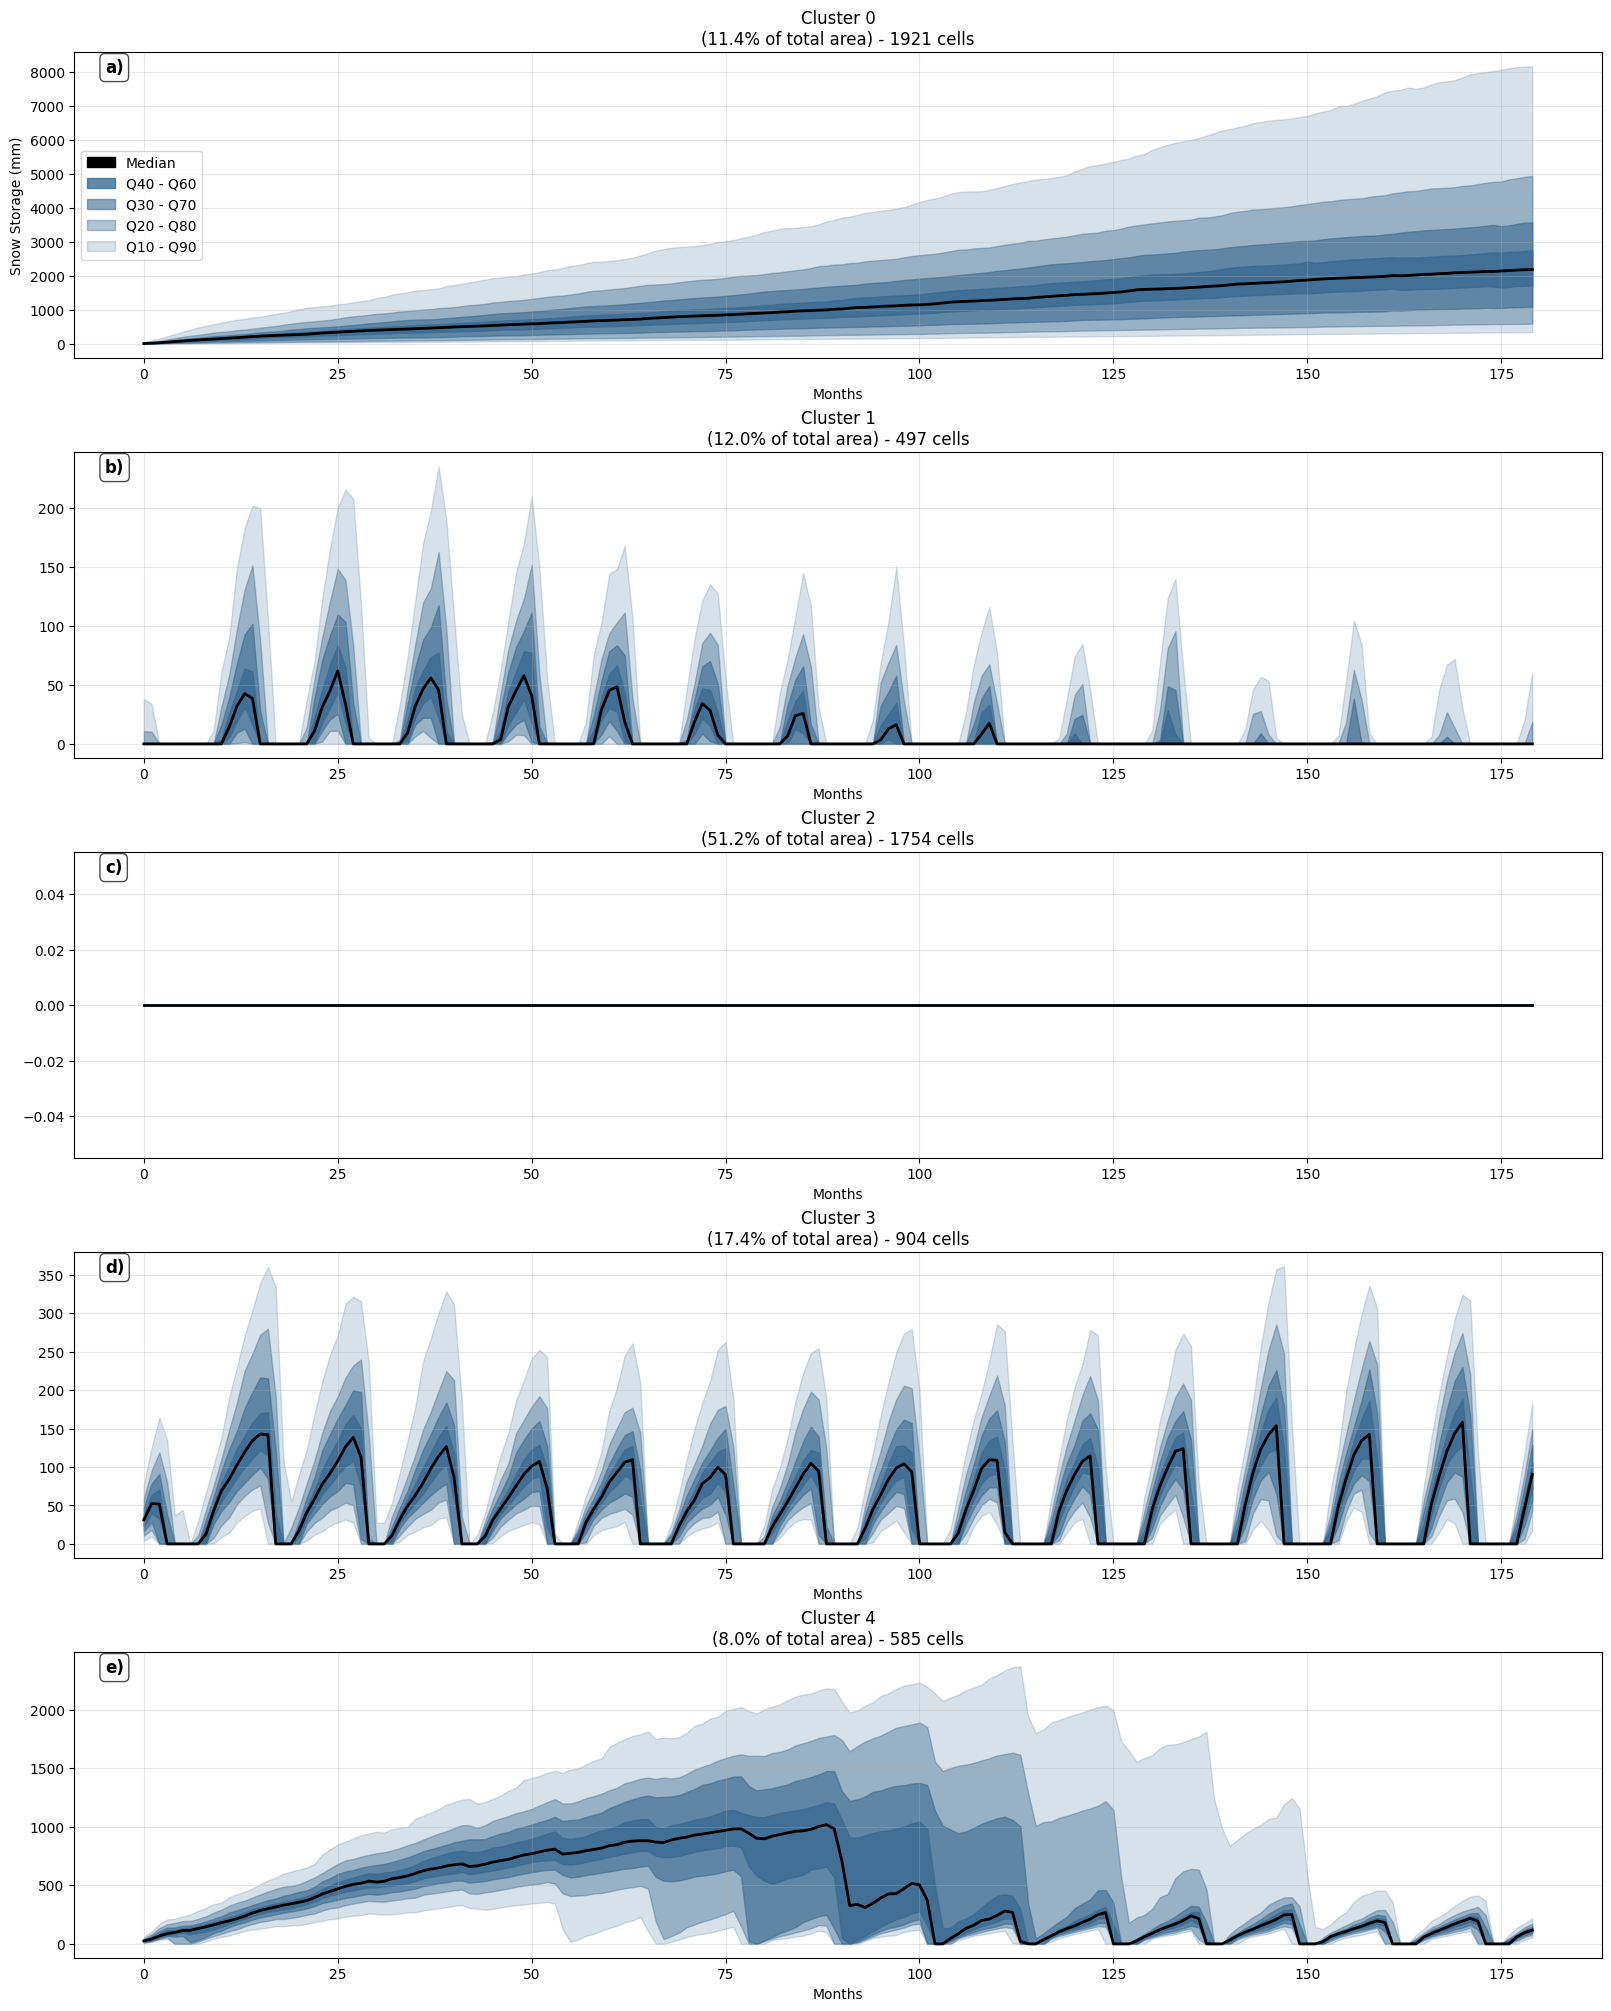

In [37]:
plot_cluster_timeseries(
    timeseries.squeeze(-1), labels, ca_x,
    n_clusters = 5,
    title = None,
    parameter_name = "Snow Storage (mm)",
    save_path = "./results/clustering",
)